In [47]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "..", "reinforce-the-puck"))

import os
from concurrent.futures import ProcessPoolExecutor

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tueplots
from components.memory import (
    BalancedMemory,
    BalancedPrioritizedMemory,
    Memory,
    PrioritizedMemory,
)
from tqdm import tqdm
from tueplots import bundles

plt.rcParams.update({"figure.dpi": 175})
plt.rcParams.update(bundles.neurips2024(family="sans-serif", ncols=1))
plt.rcParams.update(
    {
        "font.size": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "legend.title_fontsize": 12,
    }
)

In [48]:
# Load data
import os
import pandas as pd


def load_tensorboard_data(base_dir, env_name):
    """
    Load TensorBoard CSV data into a single DataFrame.

    Args:
        base_dir (str): The base directory containing metric folders and CSV files.

    Returns:
        pd.DataFrame: A DataFrame containing all the data with additional columns for metric, runname, and algorithm.
    """
    data_frames = []

    # Walk through the directory structure
    for metric in os.listdir(base_dir):
        metric_path = os.path.join(base_dir, metric)
        if os.path.isdir(metric_path):
            for file in os.listdir(metric_path):
                if file.endswith(".csv"):
                    file_path = os.path.join(metric_path, file)
                    df = pd.read_csv(file_path)

                    # Split in runname and timestamp
                    runname_timestamp = os.path.splitext(file)[0]
                    runname = runname_timestamp.split("_")[0]
                    split = runname.split("-")

                    alg = split[0]
                    buffer = "er"
                    if len(split) > 1:
                        buffer = split[1]

                    df["Metric"] = metric
                    df["RunName"] = runname_timestamp
                    df["Algorithm"] = alg
                    df["Buffer"] = buffer
                    df["Algorithm-Buffer"] = f"{alg}-{buffer}"

                    data_frames.append(df)

    combined_df = pd.concat(data_frames, ignore_index=True)
    combined_df["Environment"] = env_name
    return combined_df


pendulum = load_tensorboard_data("PendulumEval", "Pendulum")
half_cheetah = load_tensorboard_data("HalfCheetahEval", "HalfCheetah")
lunar_lander = load_tensorboard_data("LunaEval", "Lunar Lander")
combined_data = pd.concat(
    [pendulum, half_cheetah, lunar_lander], ignore_index=True
).reset_index(drop=True)
combined_data

,Wall time,Step,Value,Metric,RunName,Algorithm,Buffer,Algorithm-Buffer,Environment
0,1.739902e+09,510,-7517.972656,EvalReward,td3-per_2025-02-18_19-02-38_100,td3,per,td3-per,Pendulum
1,1.739902e+09,1011,-168.803101,EvalReward,td3-per_2025-02-18_19-02-38_100,td3,per,td3-per,Pendulum
2,1.739902e+09,1512,-157.777557,EvalReward,td3-per_2025-02-18_19-02-38_100,td3,per,td3-per,Pendulum
3,1.739902e+09,2013,-157.430328,EvalReward,td3-per_2025-02-18_19-02-38_100,td3,per,td3-per,Pendulum
4,1.739902e+09,2514,-182.787949,EvalReward,td3-per_2025-02-18_19-02-38_100,td3,per,td3-per,Pendulum
...,...,...,...,...,...,...,...,...,...
189077,1.739956e+09,9998,-80.209740,Reward,td3-per_2025-02-19_09-11-47_100,td3,per,td3-per,Lunar Lander
189078,1.739956e+09,10001,36.581528,Reward,td3-per_2025-02-19_09-11-47_100,td3,per,td3-per,Lunar Lander
189079,1.739956e+09,10006,36.581528,Reward,td3-per_2025-02-19_09-11-47_100,td3,per,td3-per,Lunar Lander
189080,1.739956e+09,10012,-4.173558,Reward,td3-per_2025-02-19_09-11-47_100,td3,per,td3-per,Lunar Lander


In [49]:
copy = combined_data.copy()
combined_data["Metric"].unique()

array(['EvalReward', 'Reward', 'Loss', 'ActorLoss', 'AlphaLoss'],
      dtype=object)

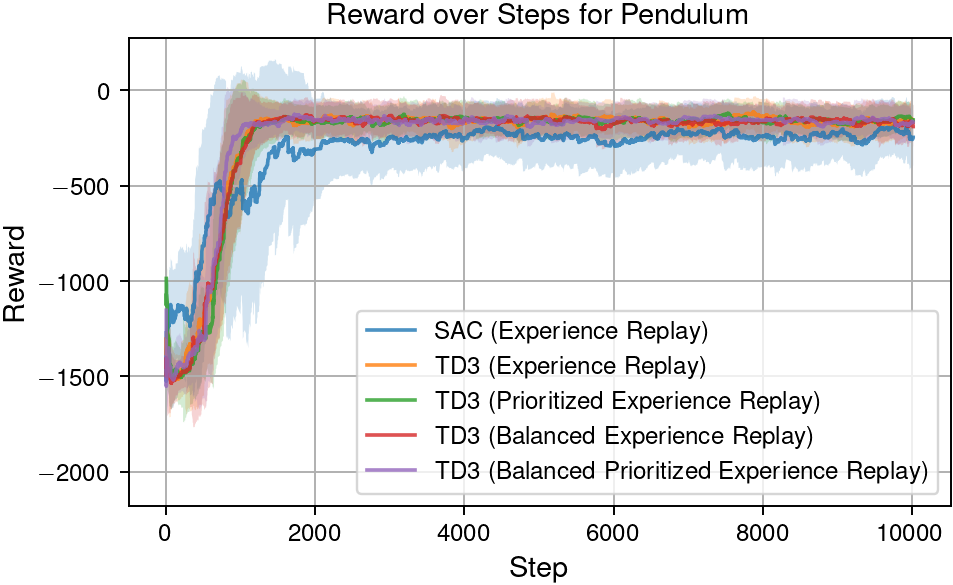

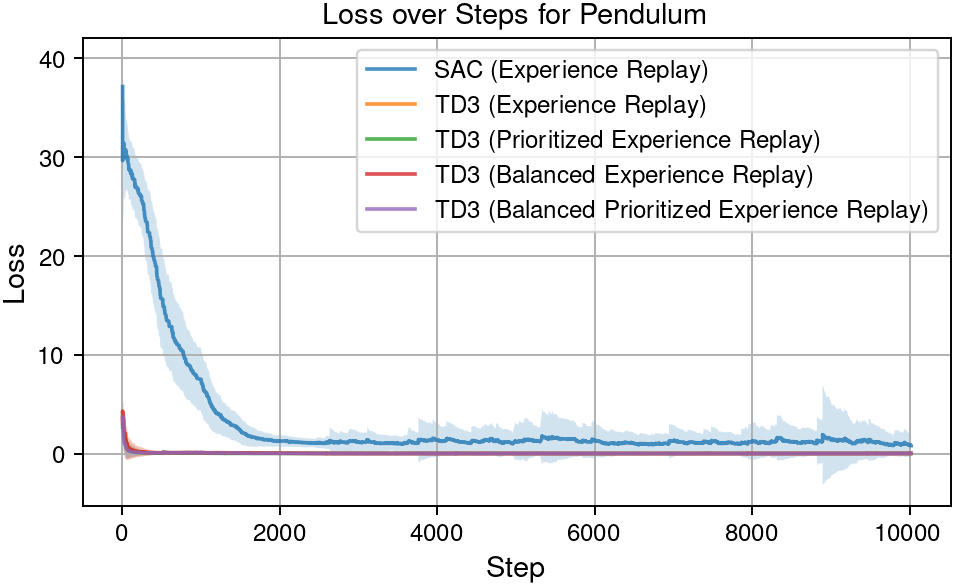

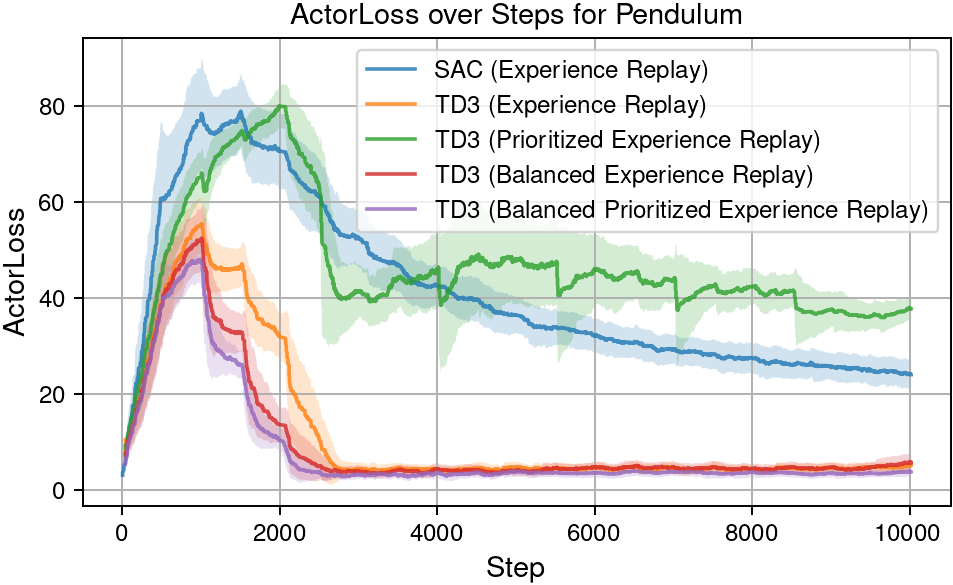

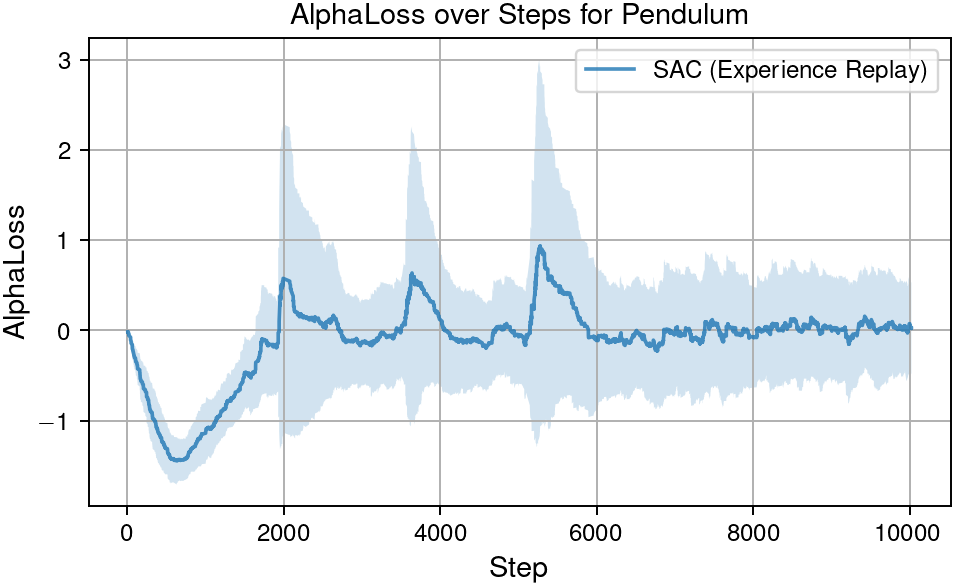

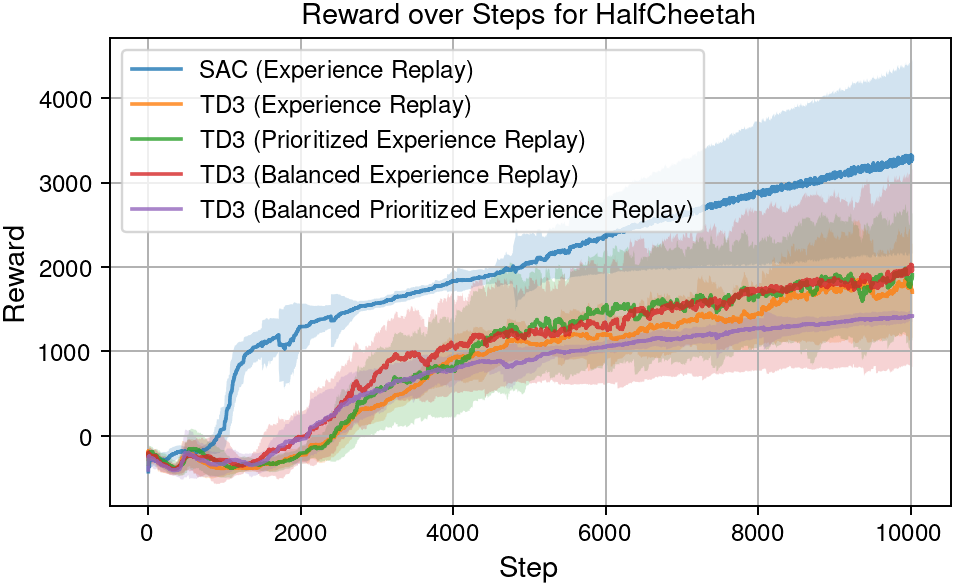

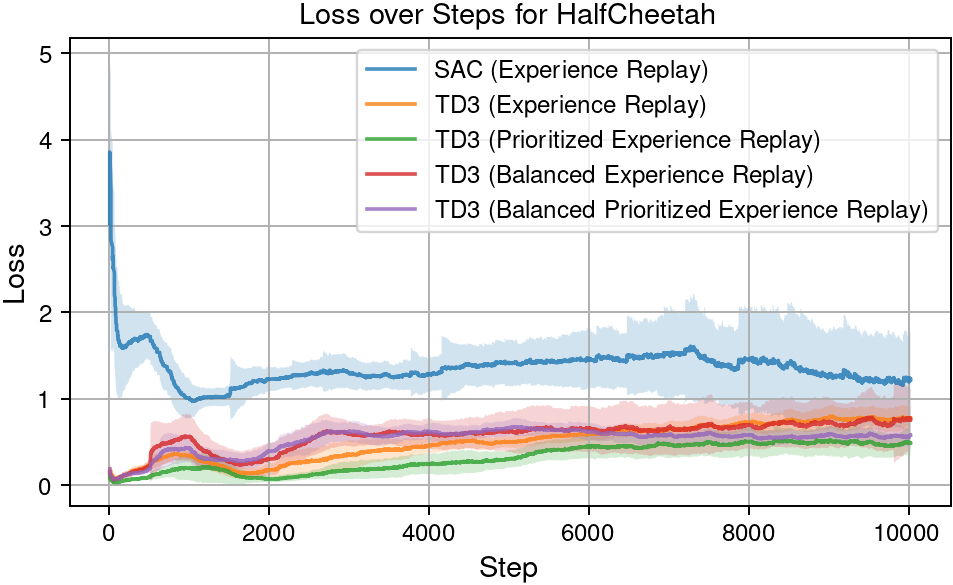

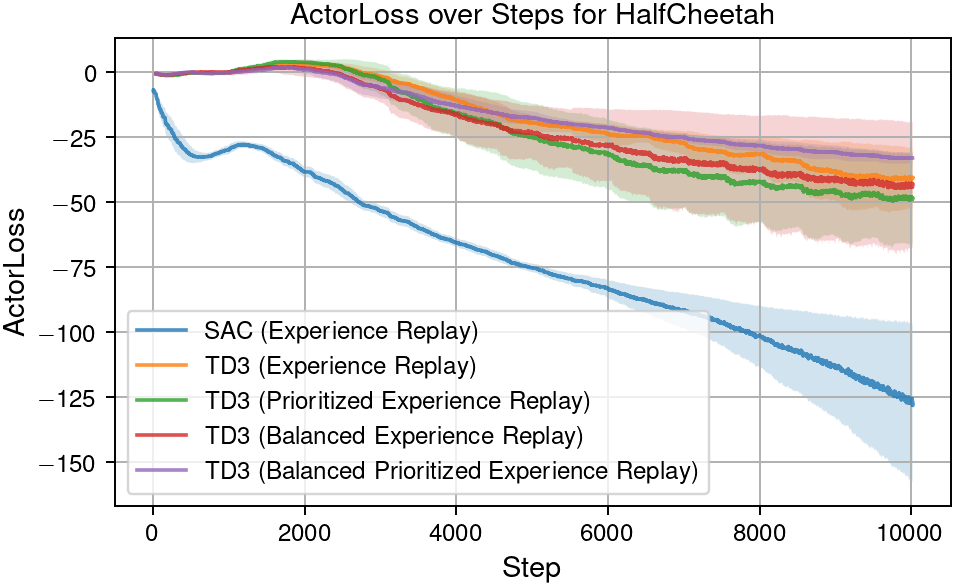

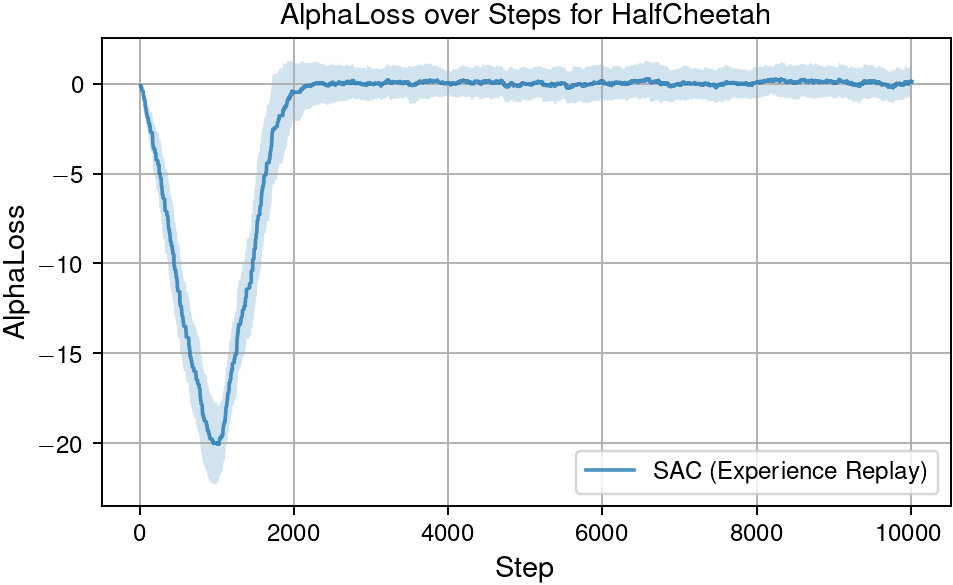

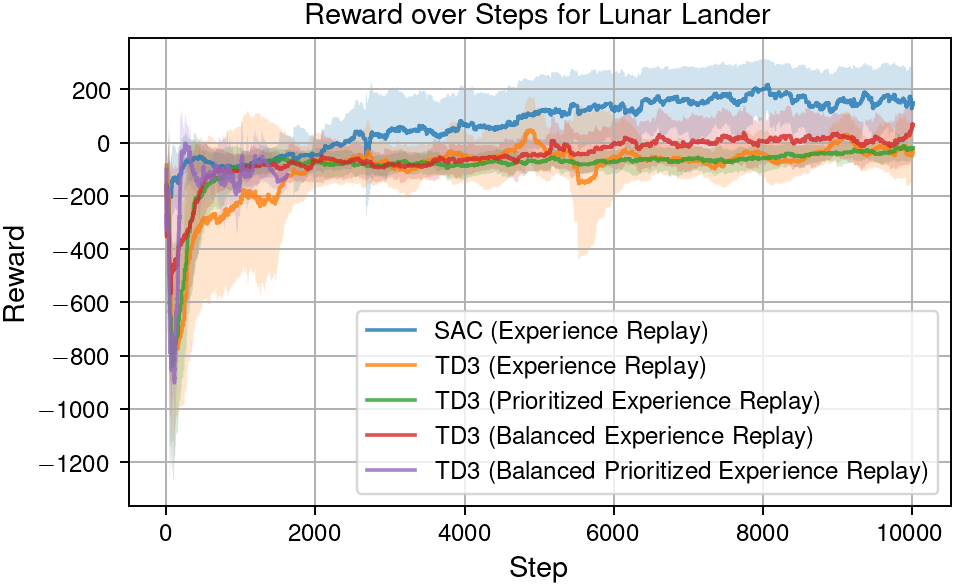

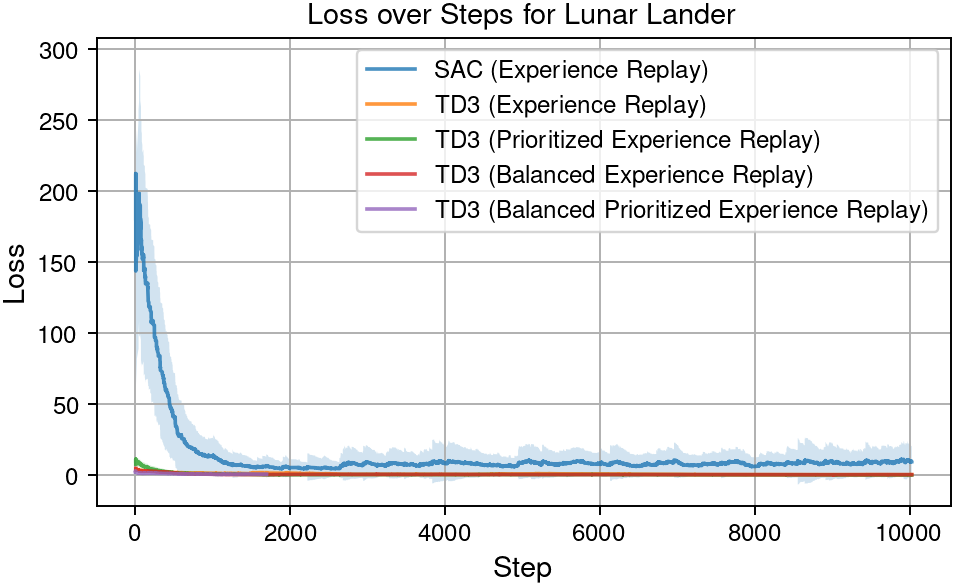

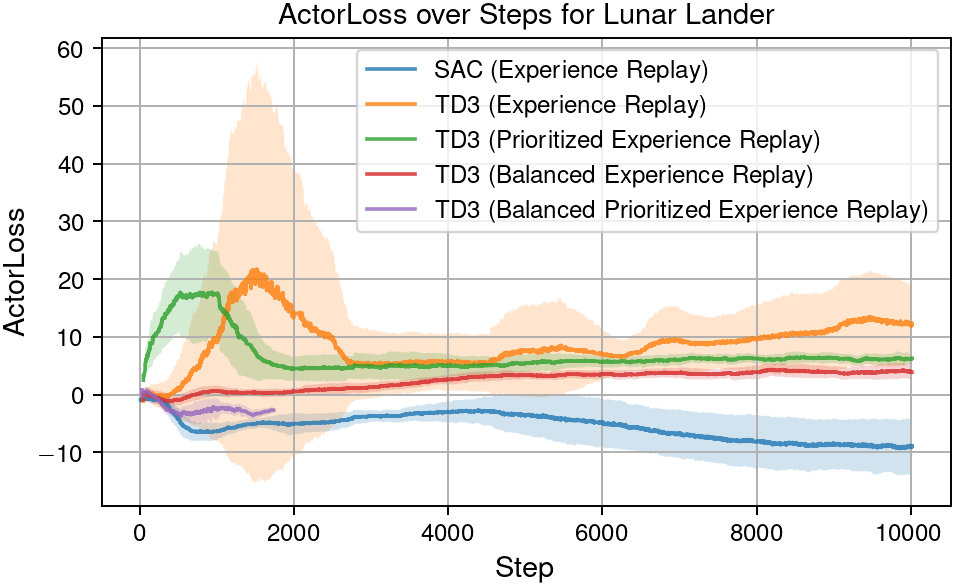

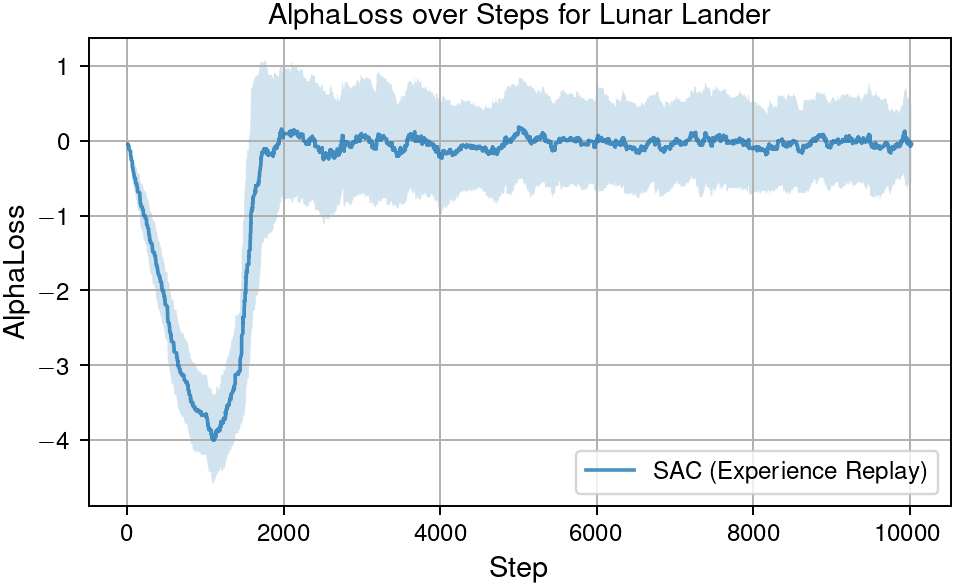

In [50]:
# Generate plots
buffer2name = {
    "er": "Experience Replay",
    "per": "Prioritized Experience Replay",
    "ber": "Balanced Experience Replay",
    "bper": "Balanced Prioritized Experience Replay",
}

# Metrics
metric2window = {
    "Reward": 100,
    "EvalReward": 1,
    "Loss": 100,
    "ActorLoss": 100,
    "AlphaLoss": 100,
}

# Sorting order
sort_order = {
    "er": 0,
    "per": 1,
    "ber": 2,
    "bper": 3,
}


# Plotting
def plot_metrics(data, b2n, m2w, metrics, environments):
    num_plots = len(metrics)
    num_envs = len(environments)
    # fig, ax = plt.subplots(num_plots, num_envs, figsize=(12, 4 * num_plots))
    for e, env in enumerate(environments):
        # row_axs = ax[:, e] if num_envs > 1 else ax
        env_data = data[data["Environment"] == env]
        for i, metric in enumerate(metrics):
            fig, ax = plt.subplots(1, 1)
            metric_data = env_data[env_data["Metric"] == metric]
            # axs = row_axs[i] if num_plots > 1 else row_axs
            axs = ax
            metric_data = metric_data.sort_values(
                by=["Algorithm", "Buffer"], key=lambda x: x.map(sort_order)
            )
            for alg_buffer in metric_data["Algorithm-Buffer"].unique():
                alg_data = metric_data[
                    metric_data["Algorithm-Buffer"] == alg_buffer
                ].sort_values(by="Step")

                buffer = alg_buffer.split("-")[1]
                alg = alg_buffer.split("-")[0]
                name = f"{alg.upper()} ({b2n[buffer]})"
                window = m2w[metric]

                # Exponential smoothing
                moving_avg = alg_data["Value"].ewm(span=window).mean()
                bounds = (
                    moving_avg - alg_data["Value"].ewm(span=window).std(),
                    moving_avg + alg_data["Value"].ewm(span=window).std(),
                )

                if window <= 1:
                    # Smoothing not possible
                    moving_avg = alg_data["Value"]

                axs.plot(
                    alg_data["Step"],
                    moving_avg,
                    label=name,
                    alpha=0.8,
                )

                if window > 1:
                    axs.fill_between(
                        alg_data["Step"],
                        bounds[0],
                        bounds[1],
                        alpha=0.2,
                    )
            axs.set_xlabel("Step")
            axs.set_ylabel(metric)
            axs.set_title(f"{metric} over Steps for {env}")
            axs.grid()
            axs.legend()
            plt.show()


plot_metrics(
    copy,
    buffer2name,
    metric2window,
    ["Reward", "Loss", "ActorLoss", "AlphaLoss"],
    ["Pendulum", "HalfCheetah", "Lunar Lander"],
)